In [1]:
from constants import users_list, data_path
from lib import spoti, genre_normalizer, plotting, preprocessing, dimensionality_reduction, user_similarities

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import json
import os
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.nn import functional as F
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import mean_squared_error
import random
import time
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors, NeighborhoodComponentsAnalysis
from sklearn.metrics import pairwise_distances
import pickle
import numpy as np
from typing import List, Dict, Tuple, Optional, Any, Callable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display, HTML
from lib.matrix_dataset import MatrixDataset
from recommenders.vae import MultiVAE
from recommenders.metrics import NDCG_binary_at_k_batch, Recall_at_k_batch, mpr
import datetime

In [2]:
%load_ext tensorboard

In [3]:
LOGS_BASE_PATH = os.path.join("logs")
def get_current_time():
    return datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

summary_writer = SummaryWriter()

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    device = mps_device
    x = torch.ones(1, device=mps_device)
    print(x)
else:
    print ("MPS device not found.")

if device == torch.device("cuda"):
    dtype = torch.float32
    print("Using CUDA.")
elif device == torch.device("cpu"):
    dtype = torch.float64
    print("Using CPU.")
elif device == torch.device("mps"):
    dtype = torch.float32
    print("Using MPS.")

# device = "cpu"
# dtype = torch.float32

tensor([1.], device='mps:0')
Using MPS.


# Import data

In [5]:
df = spoti.load_all_tracks(
    base_path=data_path.DATA_PATH,
    users=users_list.USERS,
    load_spotify_tracks=False,
    penality_factors={"short_term": 1, "medium_term": 1, "long_term": 1},
)
df

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196426,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,medium_term,1.00,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,137533,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,medium_term,0.98,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162906,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,medium_term,0.96,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,89749,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,medium_term,0.94,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,174044,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,medium_term,0.92,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12424,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,251880,False,{'isrc': 'GBN9Y1100001'},{'spotify': 'https://open.spotify.com/track/3z...,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,3z7dWKRsjDNM24ohLKZBnA,...,NaN,NaN,dany,1967,"[rock, rock, rock, rock, rock, rock, rock]",2022-12-30 08:42:31+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12425,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,193853,False,{'isrc': 'GBLTP1700005'},{'spotify': 'https://open.spotify.com/track/1V...,https://api.spotify.com/v1/tracks/1VofMhhL98pe...,1VofMhhL98pewltVGBSmCW,...,NaN,NaN,dany,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:07+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12426,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,295493,False,{'isrc': 'GBLTP1700011'},{'spotify': 'https://open.spotify.com/track/0K...,https://api.spotify.com/v1/tracks/0KE7apgczHNY...,0KE7apgczHNYiXIvMUY0Fc,...,NaN,NaN,dany,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:13+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12427,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,467306,False,{'isrc': 'GBLTP1700014'},{'spotify': 'https://open.spotify.com/track/6v...,https://api.spotify.com/v1/tracks/6vbRA9yAAgIX...,6vbRA9yAAgIXtDlmhyNqPq,...,NaN,N

## Setup the dataset

In [6]:
df_matrix_mf = df.copy()
df_matrix_mf.loc[df_matrix_mf["type"] == "liked_track", "affinity"] = 0.5
df_matrix_mf.loc[df_matrix_mf["type"] == "playlist", "affinity"] = 0.3

used_types = ["top_track", "liked_track", "playlist"]
# used_types = ["top_track"]
df_matrix_mf = df_matrix_mf[df["type"].isin(used_types)]
df_matrix_mf[["username", "id", "affinity"] + spoti.NUMERICAL_FEATURES]
df_matrix_mf["affinity"] *= 100

In [7]:
# df_matrix_mf = pd.read_csv(os.path.join(data_path.DATA_PATH, "artificial_data.csv"), index_col=0)

In [8]:
df_matrix_mf = df_matrix_mf.sample(frac=1)
df_matrix_mf

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
6703,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,[],1,270333,False,{'isrc': 'USMO17300044'},{'spotify': 'https://open.spotify.com/track/2l...,https://api.spotify.com/v1/tracks/2lNgKt1ssKQ1...,2lNgKt1ssKQ140nbYHmxvQ,...,NaN,30.0,owen,1973,"[rnb, motown, rnb, rnb, quiet storm, rnb]",2020-11-17 18:26:48+00:00,False,True,darmanger,1IOv4NlSK5mbx22XvvOkkI
11224,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,224258,False,{'isrc': 'USAT21500395'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2S5LNtRVRPbX...,2S5LNtRVRPbXk01yRQ14sZ,...,NaN,30.0,paul,2015,"[pop, rap, pop, pop]",2020-08-09 14:13:22+00:00,False,True,paulwissemberg1,4AORxF8bAWa58AdnS8w18a
6815,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,[],1,143969,True,{'isrc': 'QMEU31704830'},{'spotify': 'https://open.spotify.com/track/0A...,https://api.spotify.com/v1/tracks/0AICBlLzFCTp...,0AICBlLzFCTpUqmAbtzB2z,...,NaN,30.0,owen,2017,"[rap, rap, rap]",2020-12-10 12:47:37+00:00,False,True,owen.gombas,7KnMV0x6tVlfiHL3WfHhNn
10064,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,203093,True,{'isrc': 'USRC11901510'},{'spotify': 'https://open.spotify.com/track/7f...,https://api.spotify.com/v1/tracks/7f5trao56t7s...,7f5trao56t7sB7f14QDTmp,...,NaN,30.0,michelle,2019,"[pop, pop]",2022-01-12 11:38:33+00:00,False,True,iceblou,26gxFjYr0jT5RSukWgdwvu
6078,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,167666,False,{'isrc': 'FR0U91501709'},{'spotify': 'https://open.spotify.com/track/4Y...,https://api.spotify.com/v1/tracks/4YWiLBMOCqfC...,4YWiLBMOCqfCOrDO224Mko,...,NaN,30.0,owen,2015,"[rap, pop]",2021-05-13 12:44:48+00:00,False,True,owen.gombas,3bp6rWaNssiLhZP431bkU7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8968,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,182826,False,{'isrc': 'USHR20747017'},{'spotify': 'https://open.spotify.com/track/0J...,https://api.spotify.com/v1/tracks/0JJP0IS4w0fJ...,0JJP0IS4w0fJx01EcrfkDe,...,NaN,50.0,michelle,2007,"[rock, punk, emo, punk]",2022-01-10 22:01:29+00:00,NaN,NaN,NaN,NaN
8008,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,131037,False,{'isrc': 'USA2P2342327'},{'spotify': 'https://open.spotify.com/track/1p...,https://api.spotify.com/v1/tracks/1p0kTGMwMtST...,1p0kTGMwMtSTcV7fAnkkQc,...,medium_term,90.0,michelle,2023,"[pop, pop]",NaT,NaN,NaN,NaN,NaN
10406,"{'album_type': 'single', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,90807,False,{'isrc': 'QZ5FN1766010'},{'spotify': 'https://open.spotify.com/track/04...,https://api.spotify.com/v1/tracks/045RJ0wlM8Mz...,045RJ0wlM8MzYV3l8jiym1,...,NaN,50.0,paul,2017,[theme],2019-10-23 17:00:00+00:00,NaN,NaN,NaN,NaN
5588,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,234160,False,{'isrc': 'FR0U91601088'},{'spotify': 'https://open.spotify.com/track/4I...,https://api.spotify.com/v1/tracks/4I7C4qn2Xv4j...,4I7C4qn2Xv4jmNtJCSJrC3,...,NaN,30.0,owen,2016,"[rap, pop]",2021-05-13 12:44:39+00:00,False,True,owen.g

In [9]:
matrix_mf = MatrixDataset(df_matrix_mf, "username", "id", "affinity", device=device, dtype=dtype)
user_interacted_with = matrix_mf.R
user_interacted_with

tensor([[  0.,   0.,   0.,  ...,   0.,   0.,   0.],
        [  0.,   0.,   0.,  ...,   0.,   0.,   0.],
        [  0.,   0.,   0.,  ...,   0.,   0.,   0.],
        ...,
        [ 80.,   0.,   0.,  ...,   0.,   0.,  80.],
        [ 50., 180.,  50.,  ...,   0.,  50.,   0.],
        [  0.,   0.,   0.,  ...,   0.,   0.,   0.]], device='mps:0')

In [10]:
user_interacted_with.shape

torch.Size([8, 6320])

In [11]:
alpha = matrix_mf.compute_alpha().item()
user_interacted_with *= alpha
alpha

0.09144702553749084

In [12]:
n_users, n_items = user_interacted_with.shape

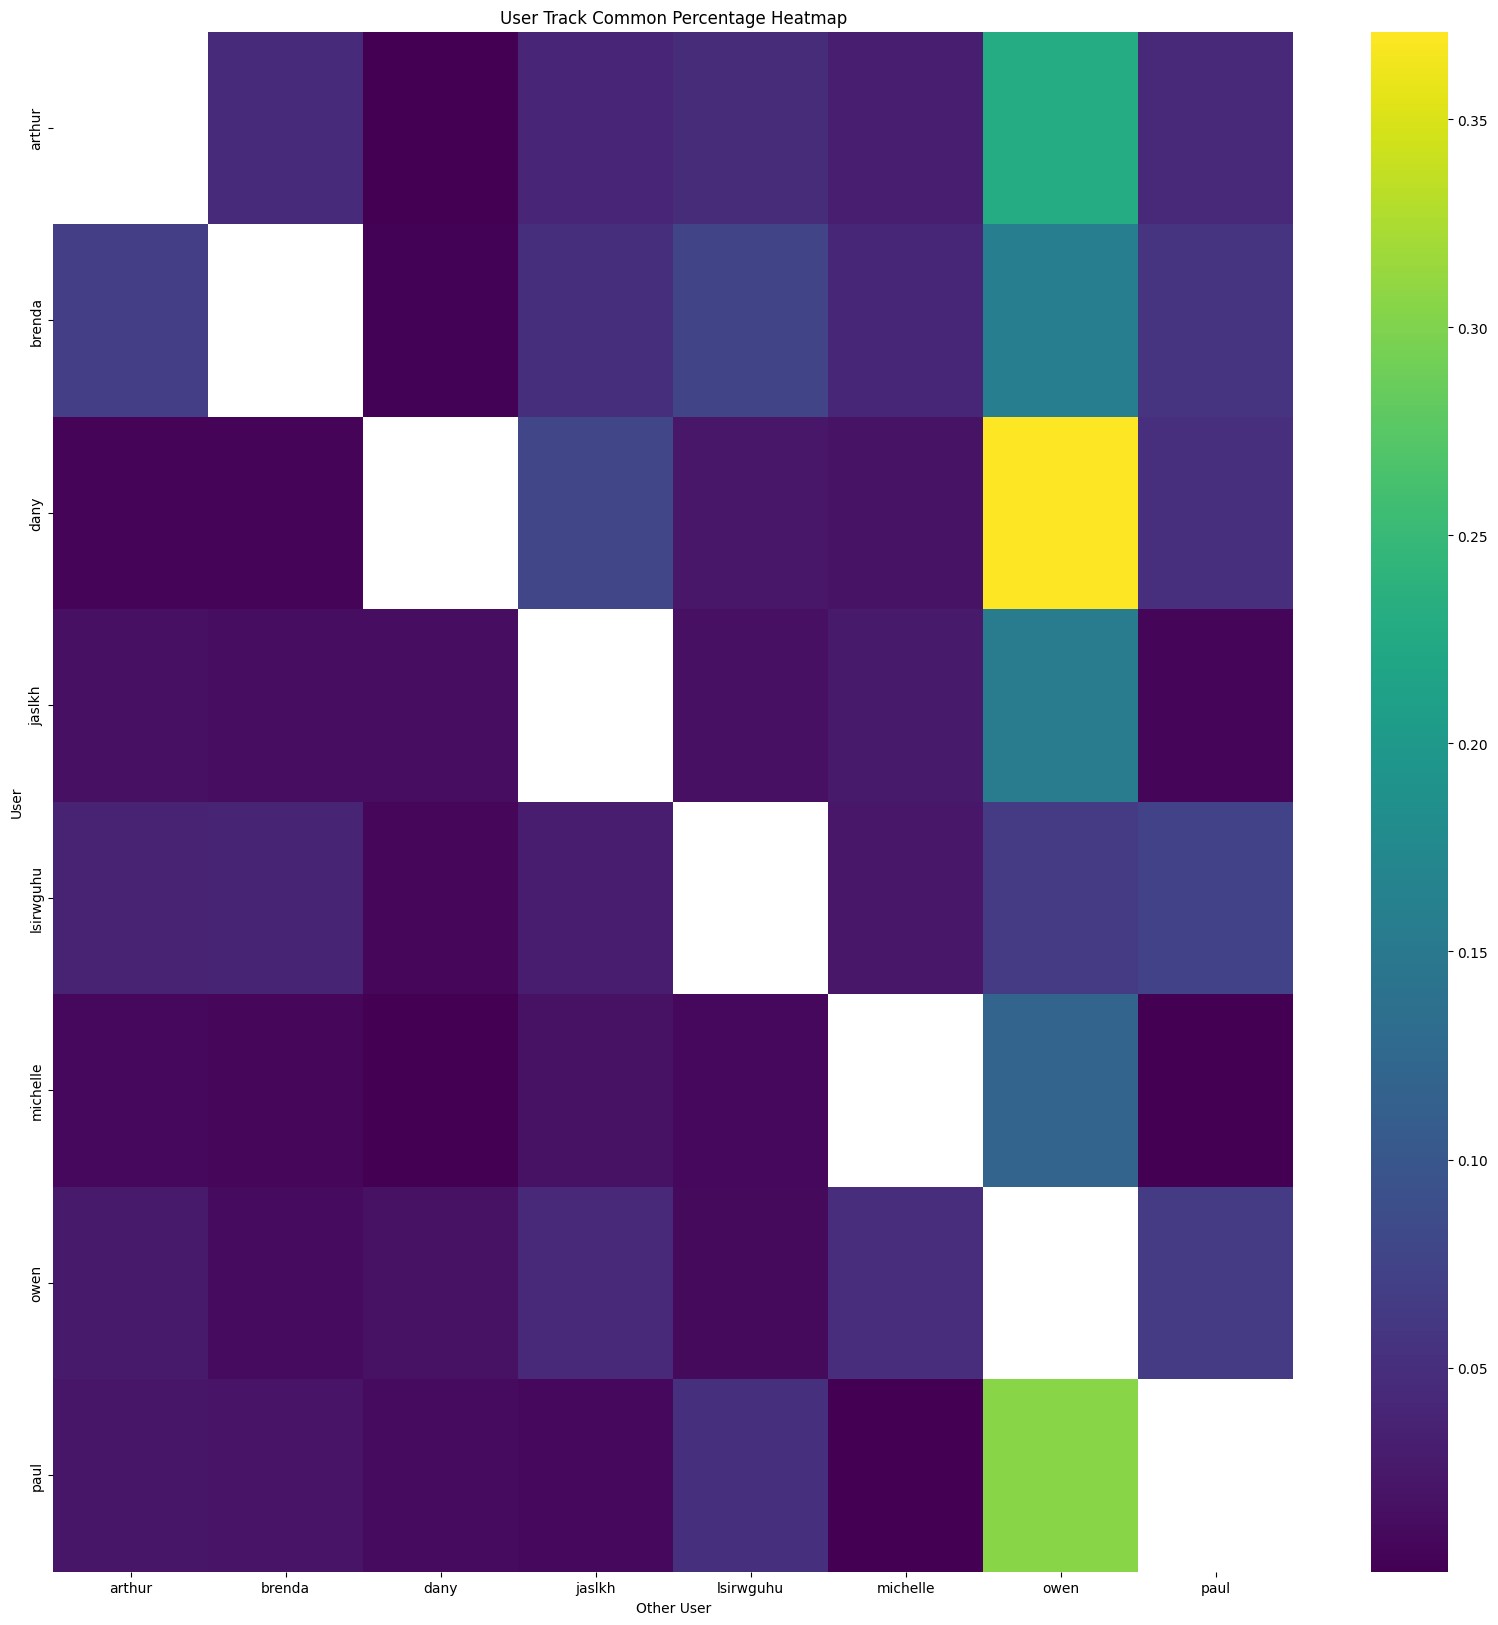

In [13]:
df_user_similarities = user_similarities.calculate_users_track_common_percentage(df_matrix_mf, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False)

In [14]:
df_matrix_mf["username"].unique()

array(['owen', 'paul', 'michelle', 'lsirwguhu', 'brenda', 'arthur',
       'jaslkh', 'dany'], dtype=object)

# Define and train the MultiVAE model

In [15]:
user_interacted_with

tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 7.3158,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  7.3158],
        [ 4.5724, 16.4605,  4.5724,  ...,  0.0000,  4.5724,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
       device='mps:0')

In [16]:
size = user_interacted_with.shape[0]
develop_percentage = 1
train_percentage = 1

develop_set = user_interacted_with[:int(size * develop_percentage)]
train_set = develop_set[:int(develop_set.shape[0] * train_percentage)]
validation_set = develop_set[int(develop_set.shape[0] * train_percentage):]
test_set = user_interacted_with[int(size * develop_percentage):]

train_dataset = TensorDataset(train_set)
validation_dataset = TensorDataset(validation_set)
test_dataset = TensorDataset(test_set)

print(f"Develop set shape: {develop_set.shape}")
print(f"Train set shape: {train_set.shape}")
print(f"Validation set shape: {validation_set.shape}")
print(f"Test set shape: {test_set.shape}")

Develop set shape: torch.Size([8, 6320])
Train set shape: torch.Size([8, 6320])
Validation set shape: torch.Size([0, 6320])
Test set shape: torch.Size([0, 6320])


In [17]:
p_dims = [200, 600, n_items]
model = MultiVAE(p_dims=p_dims).to(device=device, dtype=dtype)

In [18]:
batch_size = 32
anneal_cap = 0.2
total_anneal_steps = 200000

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
model.train_model(
    optimizer,
    train_loader,
    num_epochs=500,
    anneal_cap=anneal_cap,
    total_anneal_steps=total_anneal_steps,
    device=device,
    dtype=dtype,
    summary_writer=summary_writer,
    evalulation_matrices=(user_interacted_with, matrix_mf.sorted_R)
)

Epoch 1 Loss: 47981.0078125, MPR: 0.49891602993011475
Epoch 11 Loss: 45662.265625, MPR: 0.5015336275100708
Epoch 21 Loss: 40786.36328125, MPR: 0.5008592009544373
Epoch 31 Loss: 38768.5, MPR: 0.5002264380455017
Epoch 41 Loss: 37826.7109375, MPR: 0.5004346966743469
Epoch 51 Loss: 37597.58203125, MPR: 0.5006970167160034
Epoch 61 Loss: 37510.2109375, MPR: 0.5008690357208252
Epoch 71 Loss: 37469.296875, MPR: 0.5008982419967651
Epoch 81 Loss: 37443.7421875, MPR: 0.49973148107528687
Epoch 91 Loss: 37432.25, MPR: 0.5004684329032898
Epoch 101 Loss: 37419.27734375, MPR: 0.501143753528595
Epoch 111 Loss: 37413.1796875, MPR: 0.5003960132598877
Epoch 121 Loss: 37409.953125, MPR: 0.5010666251182556
Epoch 131 Loss: 37405.7421875, MPR: 0.5005141496658325
Epoch 141 Loss: 37403.03125, MPR: 0.5003639459609985
Epoch 151 Loss: 37404.91796875, MPR: 0.5010433793067932
Epoch 161 Loss: 37398.609375, MPR: 0.5009354948997498
Epoch 171 Loss: 37398.2890625, MPR: 0.500656247138977
Epoch 181 Loss: 37396.96484375, MP

In [19]:
if len(test_set) > 0:
    total_loss, n100_list, r20_list, r50_list = model.evaluate_model(
        training_set=train_set,
        test_set=test_set,
        batch_size=batch_size,
        anneal_cap=anneal_cap,
        total_anneal_steps=total_anneal_steps,
        device=device,
        dtype=dtype,
        summary_writer=summary_writer
    )
    mpr_value = mpr(model.recommend(user_interacted_with)[0], matrix_mf.sorted_R, device=device, dtype=dtype)
    mpr_value.item()
    print(f"Total loss: {total_loss}")
    print(f"n100_list: {n100_list}")
    print(f"r20_list: {r20_list}")
    print(f"r50_list: {r50_list}")
    print(f"MPR: {mpr_value}")

In [20]:
# retrieve users latent representations (mean and variance)
user_names = df_matrix_mf["username"].sort_values().unique().tolist()
user_names

['arthur', 'brenda', 'dany', 'jaslkh', 'lsirwguhu', 'michelle', 'owen', 'paul']

In [21]:
z, mu, std, logvar = model.get_latent_representations(user_interacted_with)

print(z.shape)
print(mu.shape)
print(std.shape)
print(logvar.shape)

torch.Size([8, 200])
torch.Size([8, 200])
torch.Size([8, 200])
torch.Size([8, 200])


In [22]:
# Define the number of points for grid, the width of the gaussian curves and color map
# dim1 = range(0, p_dims[0])
# dim2 = range(0, p_dims[0])
dim1 = range(0, 5)
dim2 = range(0, 5)

# for i in dim1:
#     for j in dim2:
#         if i >= j:
#             continue
#         # # Plot 2D latent space using and add annotations with usernames
#         # fig = px.scatter(x=z[:, i], y=z[:, j], hover_name=usersnames, color=usersnames)
#         # fig.update_traces(marker=dict(size=10))
#         # fig.update_layout(title="2D Latent Space")
#         # # Show the usernames next to the points
#         # for i_username, username in enumerate(usersnames):
#         #     fig.add_annotation(
#         #         x=z[i_username, i], y=z[i_username, j], text=username, showarrow=False, xshift=-20, yshift=15
#         #     )
#         # fig.show()
        
#         # Using sns
#         fig, ax = plt.subplots(figsize=(10, 5))
#         sns.scatterplot(x=z[:, i], y=z[:, j], hue=usersnames, ax=ax)
#         for i_username, username in enumerate(usersnames):
#             ax.text(z[i_username, i], z[i_username, j] + 0.3, username, fontsize=8)
#         ax.set_title(f"2D Latent Space ({i}, {j})")
#         ax.set_xlabel(f"z{i}")
#         ax.set_ylabel(f"z{j}")
#         plt.show()

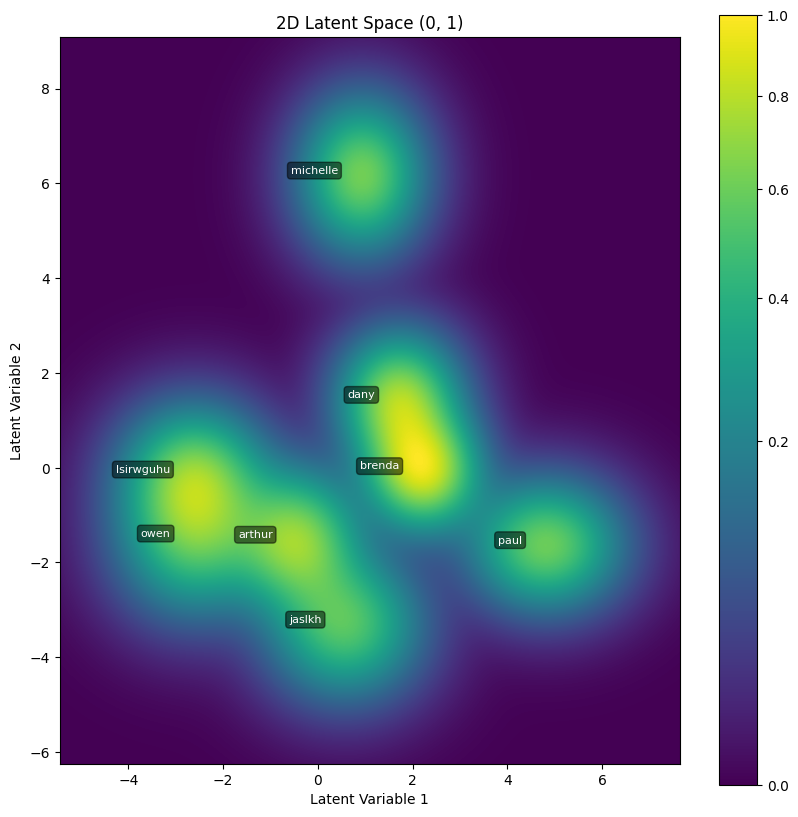

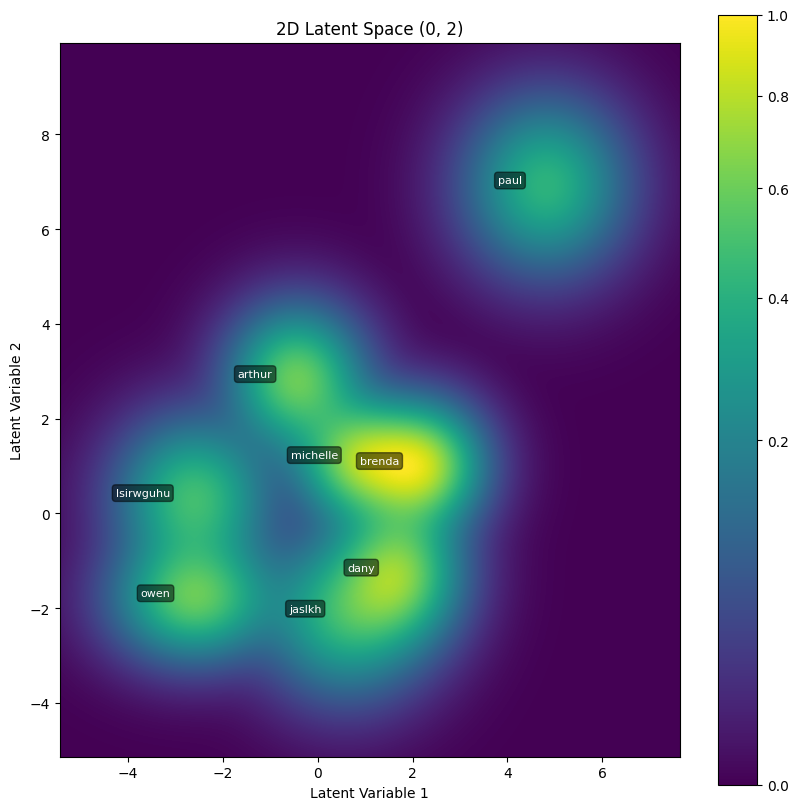

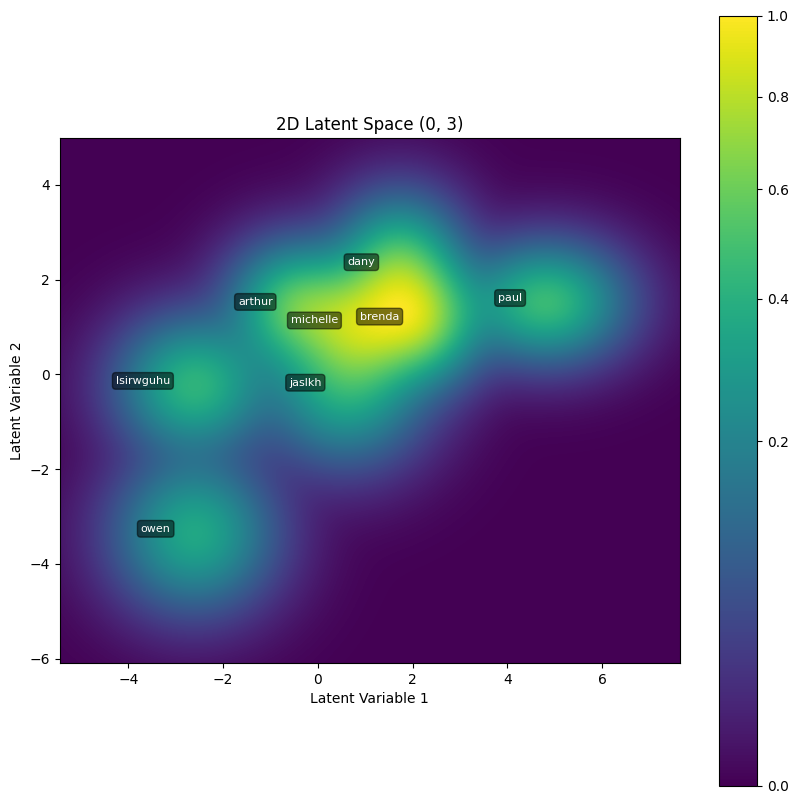

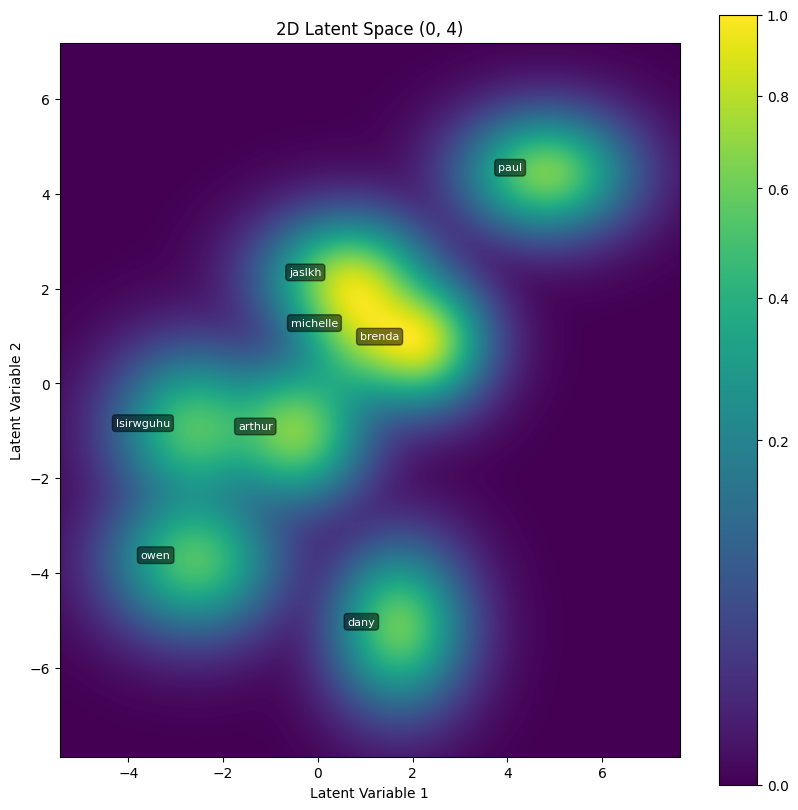

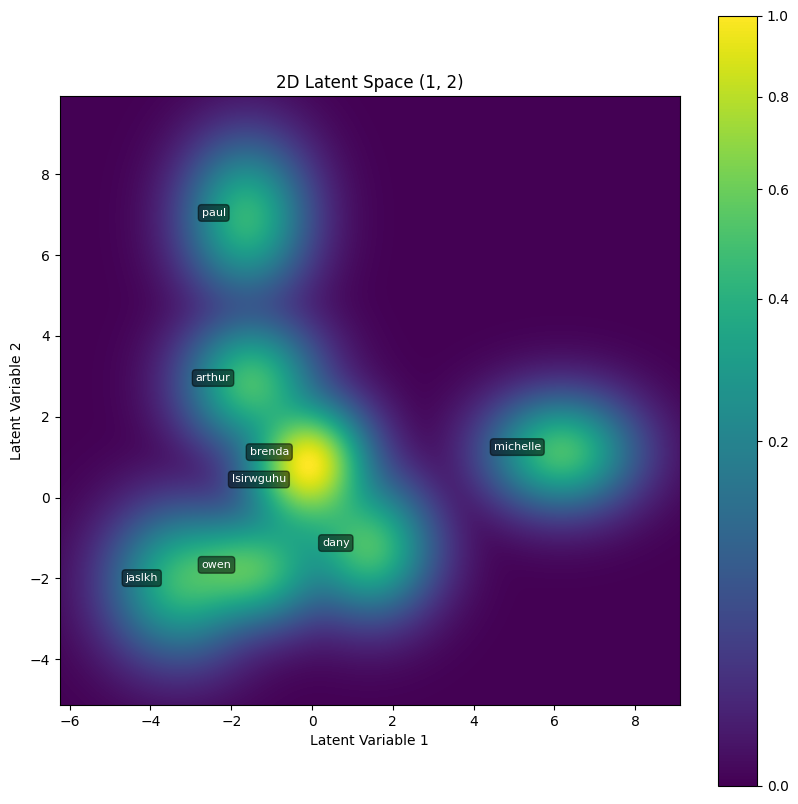

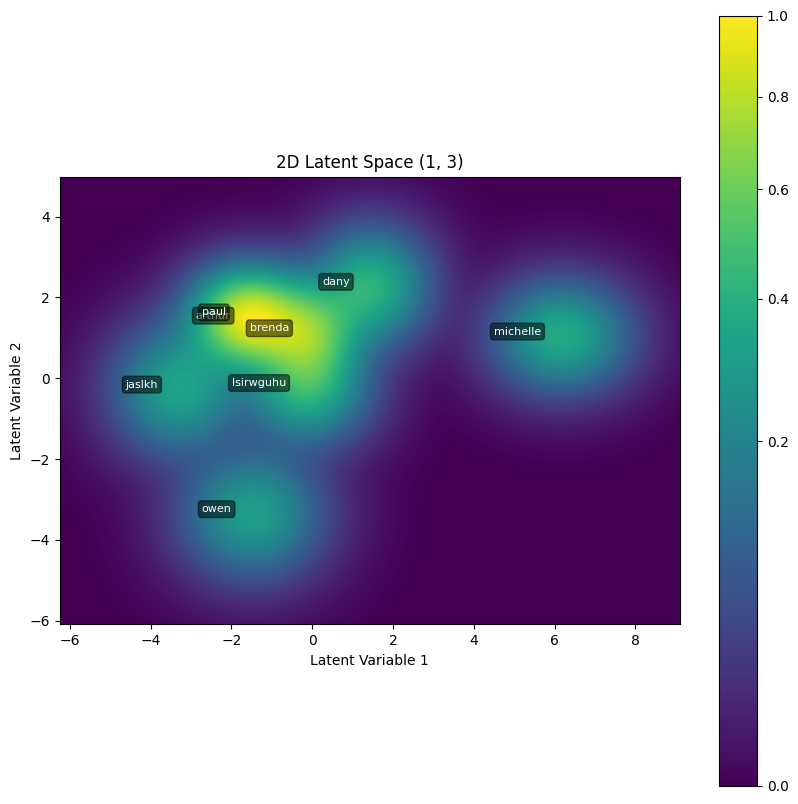

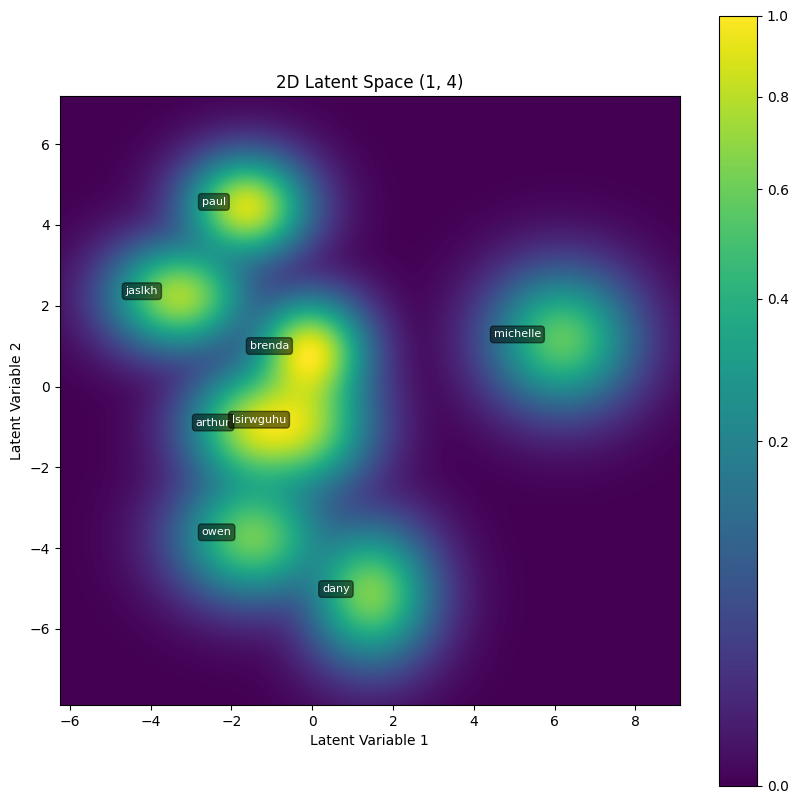

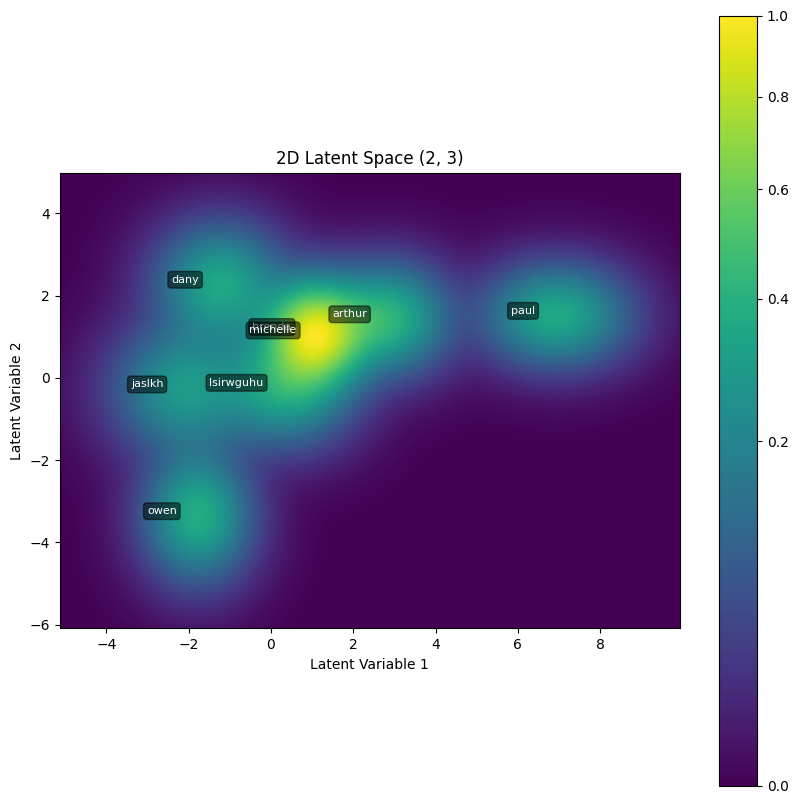

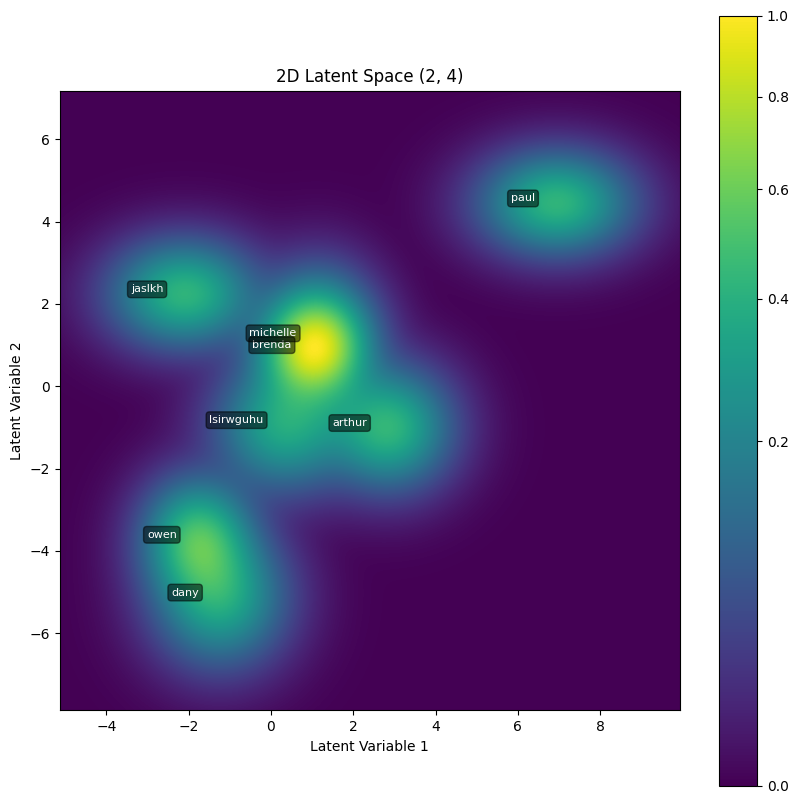

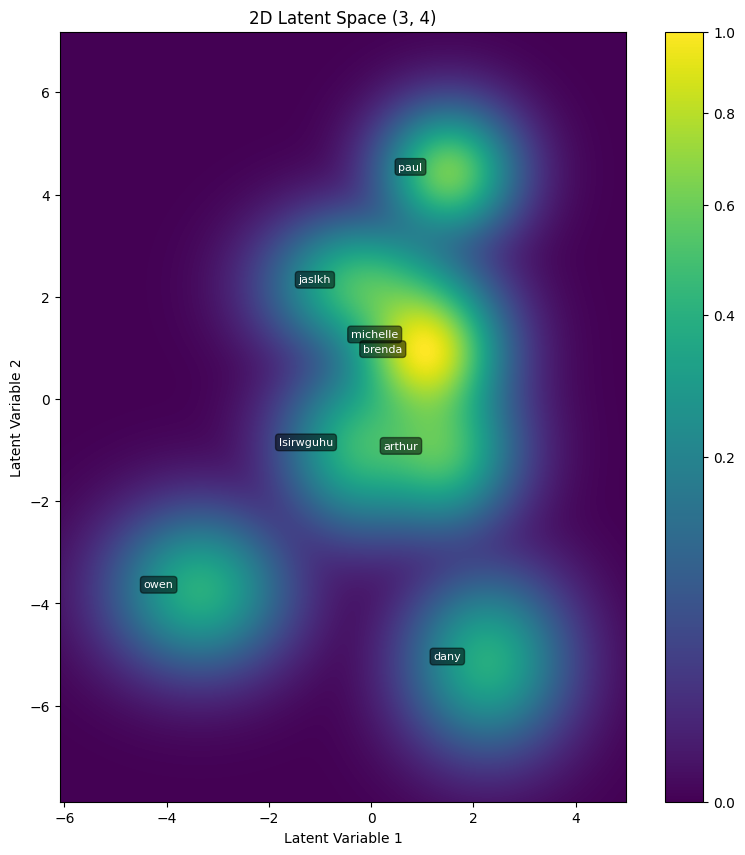

In [23]:
for i in dim1:
    for j in dim2:
        if i >= j:
            continue
        plotting.plot_multivariate_gaussian_image_with_labels(
            mu.cpu().numpy()[:, [i, j]],
            std.cpu().numpy()[:, [i, j]],
            user_names,
            title=f"2D Latent Space ({i}, {j})",
        )

In [24]:
username = "paul"
user_id = matrix_mf.usernames_to_ids([username])[0]
username = matrix_mf.ids_to_usernames([user_id])[0]
print(f"User id: {user_id}, {username}")
user_seen = matrix_mf.get_interactions_ids(user_id)
user_seen.cpu().numpy().shape

User id: 7, paul


(707,)

In [25]:
user_seen.cpu().numpy()

array([   7,   17,   21,   29,   30,   35,   47,   51,   60,   65,   66,
         72,   94,   95,  101,  111,  129,  135,  152,  155,  157,  160,
        161,  162,  166,  170,  183,  185,  188,  190,  204,  209,  217,
        226,  240,  245,  247,  259,  263,  279,  280,  311,  322,  326,
        351,  354,  357,  362,  370,  408,  411,  413,  417,  418,  421,
        431,  447,  449,  453,  464,  482,  488,  501,  518,  523,  524,
        539,  543,  553,  557,  562,  579,  580,  602,  621,  651,  652,
        663,  671,  683,  690,  707,  715,  716,  720,  729,  744,  754,
        756,  761,  762,  767,  778,  781,  784,  789,  796,  797,  802,
        809,  820,  827,  830,  842,  847,  854,  857,  861,  871,  882,
        887,  909,  910,  922,  924,  925,  928,  934,  964,  974,  992,
        993,  994,  997, 1012, 1013, 1026, 1028, 1035, 1038, 1042, 1050,
       1059, 1077, 1082, 1090, 1101, 1104, 1112, 1126, 1140, 1145, 1162,
       1165, 1169, 1171, 1172, 1174, 1179, 1185, 11

In [26]:
similar_users_ids = model.sort_similar_users(user_id=user_id, latent_representations=z)
most_similar_users = matrix_mf.ids_to_usernames(similar_users_ids.cpu().numpy())[1:]
most_similar_users

['brenda', 'lsirwguhu', 'michelle', 'owen', 'dany', 'arthur', 'jaslkh']

In [27]:
items_ids, predicted_scores = model.recommend(matrix=user_interacted_with)
recommendation_df = matrix_mf.df.copy()
recommendation_df["item_id"] = recommendation_df["id"].cat.codes.astype("int")
recommendation_df.set_index("item_id", inplace=True)
# Get df in the same order as the ids
recommendation_df = recommendation_df.loc[items_ids.cpu().numpy()[user_id]]
recommendation_df["predicted_scores"] = pd.Series(predicted_scores.cpu().numpy()[user_id], index=items_ids.cpu().numpy()[user_id])
recommendation_df = recommendation_df[recommendation_df["username"] != username]
recommendation_df = recommendation_df.drop_duplicates(subset=["username", "id"])
recommendation_df["seen"] = recommendation_df.index.isin(user_seen.cpu().numpy())
recommendation_df = recommendation_df[recommendation_df["seen"] == False]
recommendation_df = recommendation_df.sort_values(by="predicted_scores", ascending=False)

columns = spoti.PRETTY_PRINT_FEATURES
# columns = list(recommendation_df.columns)
recommendation_df[["id", "predicted_scores", "seen"] + columns].head(50)

,id,predicted_scores,seen,username,artists_names,name,release_year,popularity,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,popularity
item_id,,,,,,,,,,,,,,,,,,,,
5713,6zSpb8dQRaw0M1dK8PBwQz,1.568741,False,brenda,Elton John,Cold Heart - PNAU Remix,2021,86,0.796,0.798,0.0317,0.034000,0.000042,0.0952,0.9420,116.032,-6.312,202735,2021,86
1859,2HZLXBOnaSRhXStMLrq9fD,1.458410,False,brenda,Ghost,Mary On A Cross,2019,83,0.466,0.900,0.0447,0.000235,0.001040,0.1030,0.5610,130.020,-4.469,244804,2019,83
3407,4BM8yJ0PzBi2ZewpMTOxtx,1.385129,False,brenda,ABBA,Fernando,1976,72,0.354,0.535,0.0303,0.627000,0.000003,0.0808,0.4340,110.821,-8.876,252960,1976,72
3758,4cS2HQ6jK80vqdY9ofpztx,1.383391,False,brenda,Shakira,She Wolf,2009,78,0.865,0.690,0.0443,0.285000,0.016200,0.2250,0.8670,121.983,-7.448,188866,2009,78
3084,3ncm3RlvFkSevHb6sXykl9,1.330205,False,brenda,Duran Duran,The Chauffeur,2018,37,0.695,0.658,0.0851,0.287000,0.000184,0.0467,0.5320,82.846,-9.174,321533,2018,37
907,12S63pY6DtPOiEIUTrHiIm,1.297045,False,brenda,Stromae,L’enfer,2022,54,0.587,0.527,0.1010,0.381000,0.000000,0.2300,0.5820,88.661,-8.417,189720,2022,54
4159,54ipXppHLA8U4yqpOFTUhr,1.294889,False,brenda,Imagine Dragons,Bones,2022,86,0.772,0.750,0.0455,0.020100,0.000000,0.0740,0.5870,114.061,-3.670,165264,2022,86
3973,4rXU1bXR72WMYyroxQSn8M,1.289020,False,brenda,Angèle,Plus de sens,2023,43,0.735,0.693,0.0390,0.305000,0.000000,0.0966,0.5250,116.989,-7.719,209605,2023,43
3057,3lKN03PDeBnXZS7sDukRBt,1.244861,False,brenda,ABBA,"Money, Money, Money",1976,75,0.787,0.704,0.0385,0.535000,0.003050,0.0890,0.6460,120.701,-6.873,186426,1976,75
